# AI-Powered Business Recommendation System

## Part 2: Data Preprocessing

This notebook demonstrates the complete machine learning pipeline for recommending digital services to businesses based on their industry, business size, digital presence, marketing budget, and business goals.

In [48]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Save Model
import joblib

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Set plot style
sns.set_style("whitegrid")

## Load Dataset

In [49]:
df = pd.read_csv("../dataset/business_dataset.csv")

# Display dataset dimensions
print(f"Dataset Shape: {df.shape}")

# Display first five records
df.head()

Dataset Shape: (500, 9)


,Business Name,Industry,Business Size,Website,Social Media,SEO Score,Budget,Goal,Recommended Service
0,"Crist, Kohler and Casper",IT Services,Small,True,Medium,77,17507,Automate Operations,Website Development
1,"McDermott, King and Kunde",Real Estate,Small,True,High,61,479768,Improve Online Presence,SEO
2,King-Kohler,E-commerce,Medium,True,Medium,71,281992,Launch Mobile App,App Development
3,Hauck-Ferry,Retail,Small,False,Medium,63,696013,Improve Online Presence,Website Development
4,Veum-Hills,Manufacturing,Small,True,Low,98,736705,Expand Business,Branding


## Dataset Overview

In [50]:
# Check the number of rows and columns
df.shape

(500, 9)

In [51]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Business Name        500 non-null    str  
 1   Industry             500 non-null    str  
 2   Business Size        500 non-null    str  
 3   Website              500 non-null    bool 
 4   Social Media         500 non-null    str  
 5   SEO Score            500 non-null    int64
 6   Budget               500 non-null    int64
 7   Goal                 500 non-null    str  
 8   Recommended Service  500 non-null    str  
dtypes: bool(1), int64(2), str(6)
memory usage: 31.9 KB


In [52]:
# Display statistical summary
df.describe()

,SEO Score,Budget
count,500.000000,500.000000
mean,49.658000,501175.498000
std,29.676901,291526.748284
min,0.000000,1280.000000
25%,24.000000,241115.250000
50%,50.000000,522575.000000
75%,76.000000,751275.500000
max,100.000000,997188.000000


In [53]:
# Display column names
df.columns

print(df.columns)

Index(['Business Name', 'Industry', 'Business Size', 'Website', 'Social Media',
       'SEO Score', 'Budget', 'Goal', 'Recommended Service'],
      dtype='str')


In [54]:
# Display random sample records
df.sample(5)

,Business Name,Industry,Business Size,Website,Social Media,SEO Score,Budget,Goal,Recommended Service
82,"Breitenberg, Hilll and Kris",IT Services,Small,False,Medium,82,51472,Increase Website Traffic,Branding
236,Okuneva-Considine,IT Services,Large,True,High,91,239103,Expand Business,Branding
99,"Hagenes, Casper and Fritsch",E-commerce,Large,True,Low,6,158326,Improve Customer Experience,SEO
382,Schmeler Group,Restaurant,Small,True,Low,15,815128,Improve Online Presence,SEO
400,Hansen-Willms,Healthcare,Large,True,Medium,88,946859,Increase Customers,Branding


## Data Cleaning

In [55]:
# Check missing values in each column
missing_values = df.isnull().sum()

print(missing_values)

Business Name          0
Industry               0
Business Size          0
Website                0
Social Media           0
SEO Score              0
Budget                 0
Goal                   0
Recommended Service    0
dtype: int64


In [56]:
# Count duplicate rows
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [57]:
# Display data types
df.dtypes

Business Name            str
Industry                 str
Business Size            str
Website                 bool
Social Media             str
SEO Score              int64
Budget                 int64
Goal                     str
Recommended Service      str
dtype: object

## Exploratory Data Analysis (EDA)

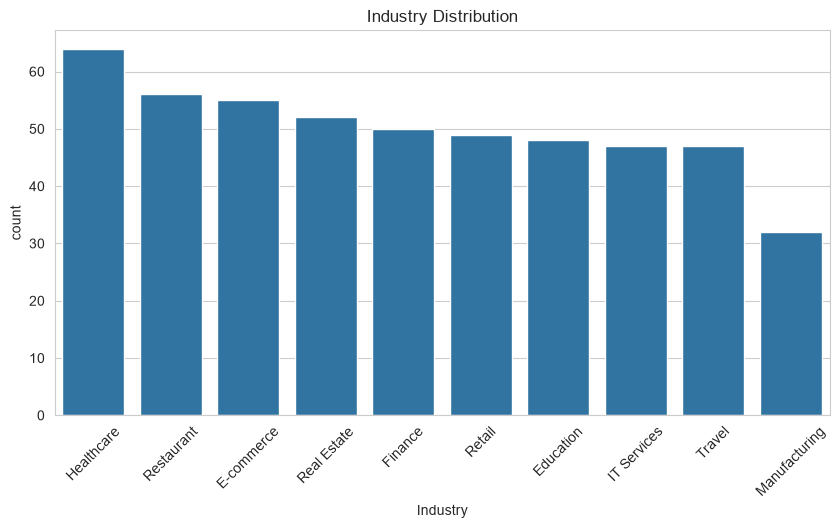

In [58]:
# Visualize industry distribution
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Industry",
    order=df["Industry"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Industry Distribution")
plt.show()

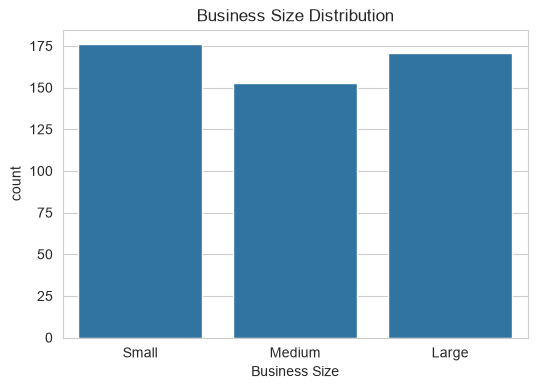

In [59]:
# Visualize business size distribution
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Business Size")

plt.title("Business Size Distribution")
plt.show()

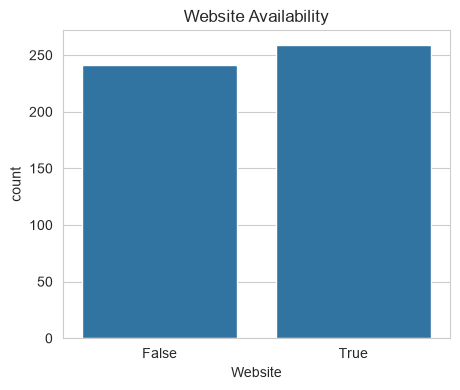

In [60]:
# Visualize website availability
plt.figure(figsize=(5,4))

sns.countplot(data=df, x="Website")

plt.title("Website Availability")
plt.show()

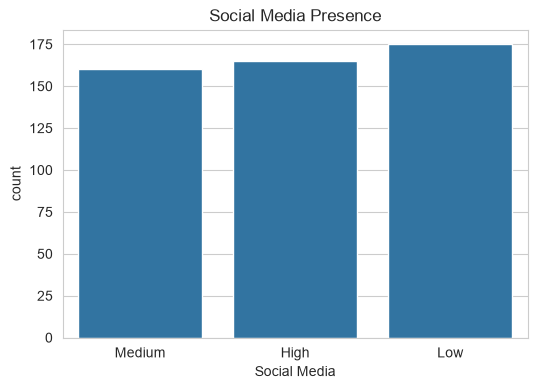

In [61]:
# Visualize social media presence
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Social Media")

plt.title("Social Media Presence")
plt.show()

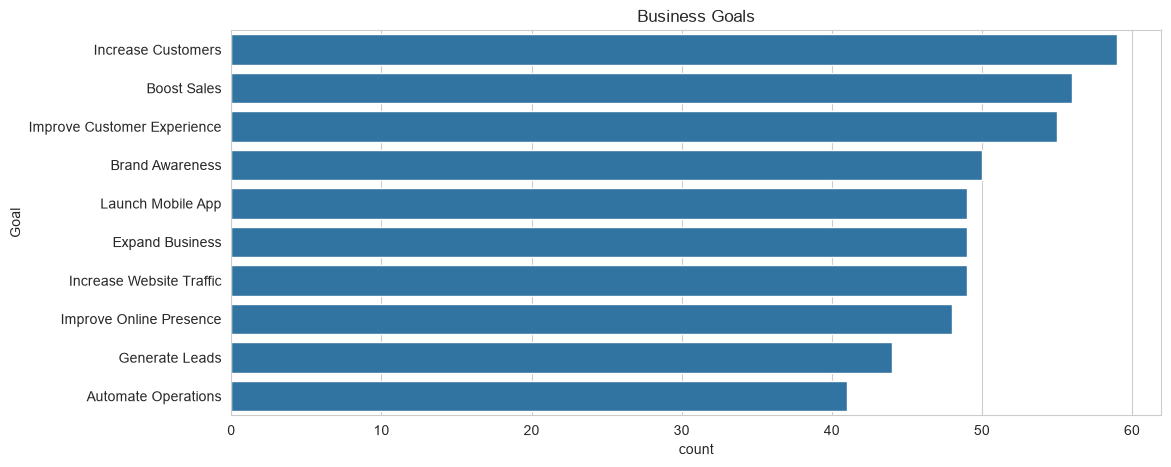

In [62]:
# Visualize business goals
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    y="Goal",
    order=df["Goal"].value_counts().index
)

plt.title("Business Goals")
plt.show()

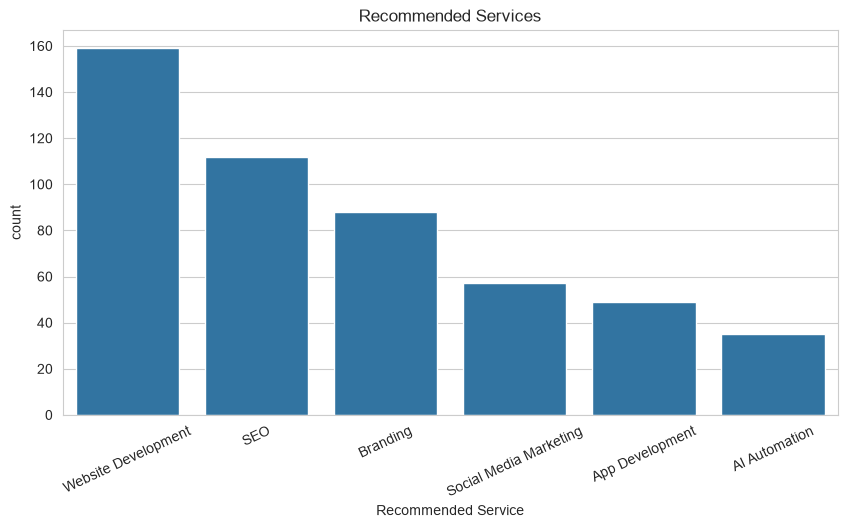

In [63]:
# Visualize target variable distribution
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Recommended Service",
    order=df["Recommended Service"].value_counts().index
)

plt.xticks(rotation=25)

plt.title("Recommended Services")

plt.show()

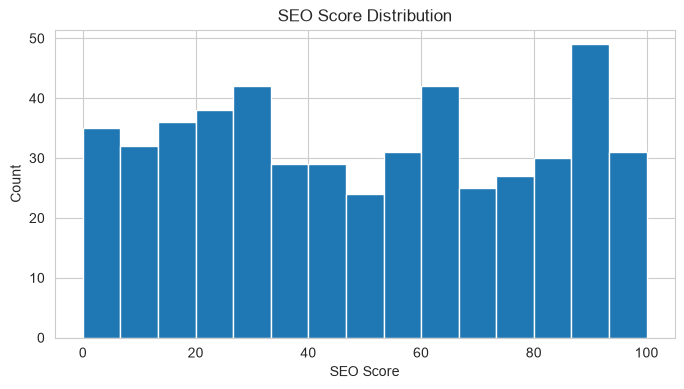

In [64]:
# Visualize SEO score distribution
plt.figure(figsize=(8,4))

plt.hist(df["SEO Score"], bins=15)

plt.title("SEO Score Distribution")

plt.xlabel("SEO Score")

plt.ylabel("Count")

plt.show()

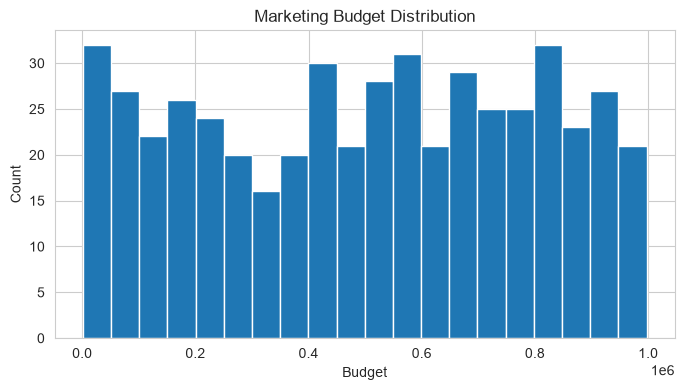

In [65]:
# Visualize marketing budget distribution
plt.figure(figsize=(8,4))

plt.hist(df["Budget"], bins=20)

plt.title("Marketing Budget Distribution")

plt.xlabel("Budget")

plt.ylabel("Count")

plt.show()

## Feature Engineering

In [66]:
# Function to categorize marketing budget
def budget_category(budget):
    if budget < 50000:
        return "Low"
    elif budget < 200000:
        return "Medium"
    else:
        return "High"

# Create new feature
df["Budget Category"] = df["Budget"].apply(budget_category)

# Display newly created feature
df[["Budget", "Budget Category"]].head(10)

,Budget,Budget Category
0,17507,Low
1,479768,High
2,281992,High
3,696013,High
4,736705,High
5,760660,High
6,733995,High
7,638025,High
8,300740,High
9,352143,High


In [67]:
# Display data types after encoding
print(df.dtypes)

# Display first five rows after encoding
df.head()

Business Name            str
Industry                 str
Business Size            str
Website                 bool
Social Media             str
SEO Score              int64
Budget                 int64
Goal                     str
Recommended Service      str
Budget Category          str
dtype: object


,Business Name,Industry,Business Size,Website,Social Media,SEO Score,Budget,Goal,Recommended Service,Budget Category
0,"Crist, Kohler and Casper",IT Services,Small,True,Medium,77,17507,Automate Operations,Website Development,Low
1,"McDermott, King and Kunde",Real Estate,Small,True,High,61,479768,Improve Online Presence,SEO,High
2,King-Kohler,E-commerce,Medium,True,Medium,71,281992,Launch Mobile App,App Development,High
3,Hauck-Ferry,Retail,Small,False,Medium,63,696013,Improve Online Presence,Website Development,High
4,Veum-Hills,Manufacturing,Small,True,Low,98,736705,Expand Business,Branding,High


## Label Encoding

In [68]:
df_encoded = df.copy()

label_encoders = {}

categorical_columns = [
    "Industry",
    "Business Size",
    "Website",
    "Social Media",
    "Goal",
    "Budget Category",
    "Recommended Service"
]

for column in categorical_columns:

    encoder = LabelEncoder()

    df_encoded[column] = encoder.fit_transform(df_encoded[column])

    label_encoders[column] = encoder

print("✅ Encoding completed successfully.")

df_encoded.head()

✅ Encoding completed successfully.


,Business Name,Industry,Business Size,Website,Social Media,SEO Score,Budget,Goal,Recommended Service,Budget Category
0,"Crist, Kohler and Casper",4,2,1,2,77,17507,0,5,1
1,"McDermott, King and Kunde",6,2,1,0,61,479768,6,3,0
2,King-Kohler,0,1,1,2,71,281992,9,1,0
3,Hauck-Ferry,8,2,0,2,63,696013,6,5,0
4,Veum-Hills,5,2,1,1,98,736705,3,2,0


In [69]:
df_encoded.dtypes

Business Name            str
Industry               int64
Business Size          int64
Website                int64
Social Media           int64
SEO Score              int64
Budget                 int64
Goal                   int64
Recommended Service    int64
Budget Category        int64
dtype: object

## Save Processed Dataset

In [70]:
# Save processed dataset for future use

df_encoded.to_csv("../dataset/business_dataset_processed.csv", index=False)

print("✅ Processed dataset saved successfully.")

✅ Processed dataset saved successfully.


## Correlation Analysis

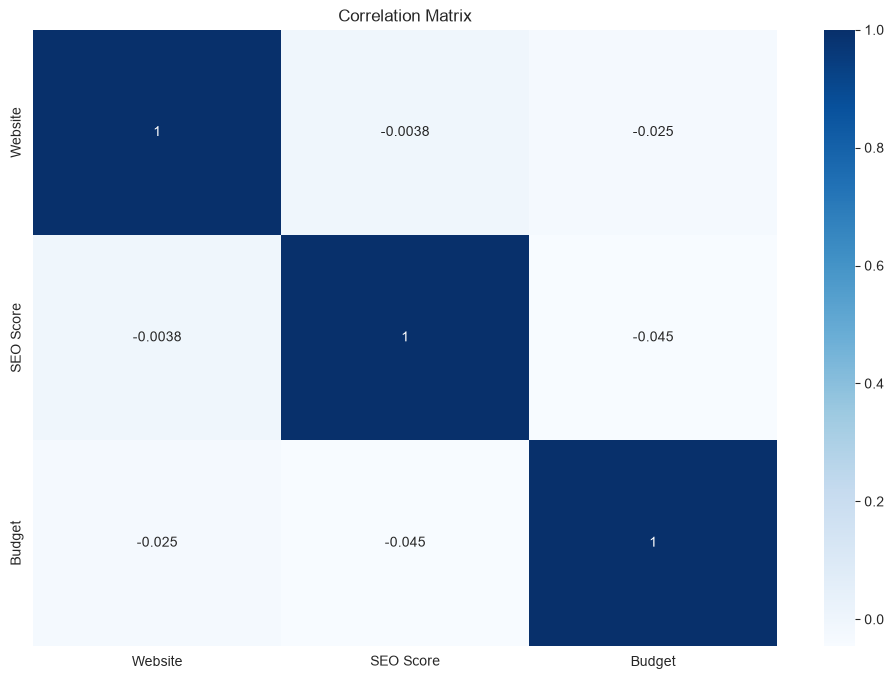

In [71]:
# Plot correlation heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

## Save Label Encoders

In [72]:
# Create models directory if it does not exist
import os

os.makedirs("../models", exist_ok=True)

# Save label encoders
joblib.dump(label_encoders, "../models/label_encoders.pkl")

['../models/label_encoders.pkl']

## Machine Learning Model

In [73]:
# Features
X = df_encoded.drop(columns=[
    "Business Name",
    "Recommended Service"
])

# Target
y = df_encoded["Recommended Service"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Features Shape: (500, 8)
Target Shape: (500,)

Training Data: (400, 8)
Testing Data : (100, 8)


## Decision Tree Classifier

In [74]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=8
)

decision_tree.fit(X_train, y_train)

# Prediction
dt_predictions = decision_tree.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


## Random Forest Classifier

In [75]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

# Prediction
rf_predictions = random_forest.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## Model Evaluation

In [76]:
def evaluate_model(model_name, y_true, predictions):

    accuracy = accuracy_score(y_true, predictions)

    precision = precision_score(
        y_true,
        predictions,
        average="weighted"
    )

    recall = recall_score(
        y_true,
        predictions,
        average="weighted"
    )

    f1 = f1_score(
        y_true,
        predictions,
        average="weighted"
    )

    print("=" * 50)
    print(model_name)
    print("=" * 50)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

    return accuracy, precision, recall, f1


dt_scores = evaluate_model(
    "Decision Tree",
    y_test,
    dt_predictions
)

rf_scores = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)

Decision Tree
Accuracy : 0.9800
Precision: 0.9820
Recall   : 0.9800
F1 Score : 0.9802
Random Forest
Accuracy : 0.9000
Precision: 0.9041
Recall   : 0.9000
F1 Score : 0.9001


## Model Comparison

In [77]:
comparison = pd.DataFrame({

    "Model":[
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        dt_scores[0],
        rf_scores[0]
    ],

    "Precision":[
        dt_scores[1],
        rf_scores[1]
    ],

    "Recall":[
        dt_scores[2],
        rf_scores[2]
    ],

    "F1 Score":[
        dt_scores[3],
        rf_scores[3]
    ]

})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.98,0.982000,0.98,0.980172
1,Random Forest,0.90,0.904127,0.90,0.900077


## Confusion Matrix

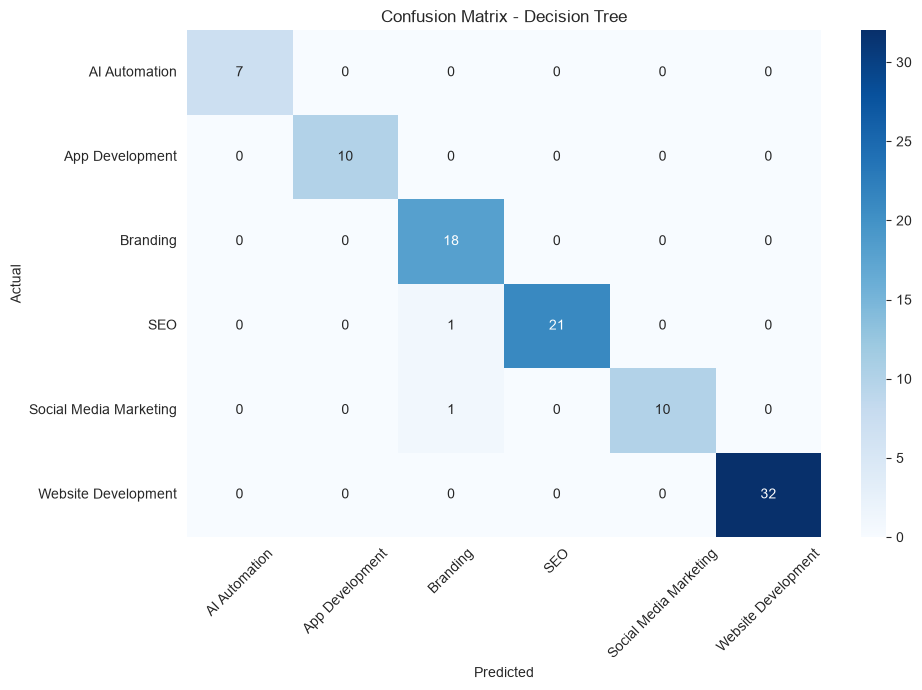

In [78]:
best_model = decision_tree

best_predictions = dt_predictions

labels = label_encoders["Recommended Service"].classes_

cm = confusion_matrix(y_test, best_predictions)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.title("Confusion Matrix - Decision Tree")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.tight_layout()

plt.show()

## Classification Report

In [79]:
target_names = label_encoders[
    "Recommended Service"
].classes_

print(
    classification_report(
        y_test,
        best_predictions,
        target_names=target_names
    )
)

                        precision    recall  f1-score   support

         AI Automation       1.00      1.00      1.00         7
       App Development       1.00      1.00      1.00        10
              Branding       0.90      1.00      0.95        18
                   SEO       1.00      0.95      0.98        22
Social Media Marketing       1.00      0.91      0.95        11
   Website Development       1.00      1.00      1.00        32

              accuracy                           0.98       100
             macro avg       0.98      0.98      0.98       100
          weighted avg       0.98      0.98      0.98       100



## Save Best Model

In [80]:
# Create models folder
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    decision_tree,
    "../models/business_recommendation_model.pkl"
)

print("✅ Best model (Decision Tree) saved successfully.")

✅ Best model (Decision Tree) saved successfully.
